<a href="https://colab.research.google.com/github/basnetutsav/college/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()




TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd

# Load the Netflix dataset
df = pd.read_csv("netflix_titles.csv")

# Show first few rows
df.head()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


✅ Dataset loaded: (8807, 12)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   


/tmp/ipython-input-2911983043.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_dist.values, y=freq_dist.index, palette="mako")


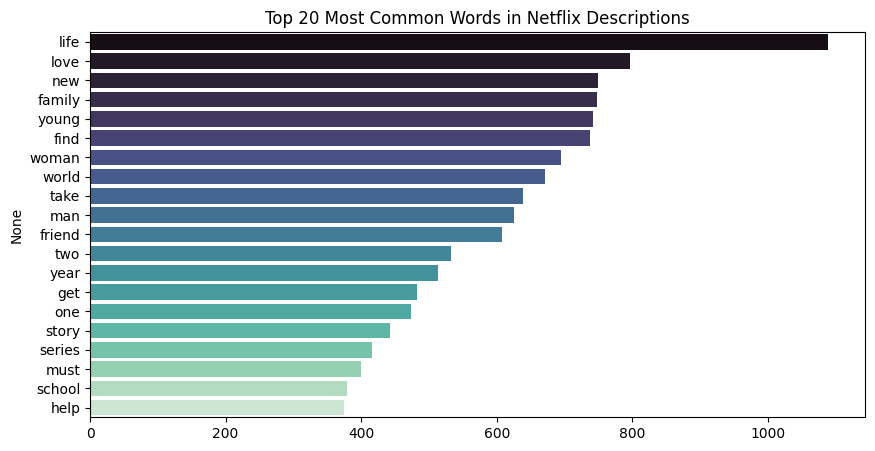

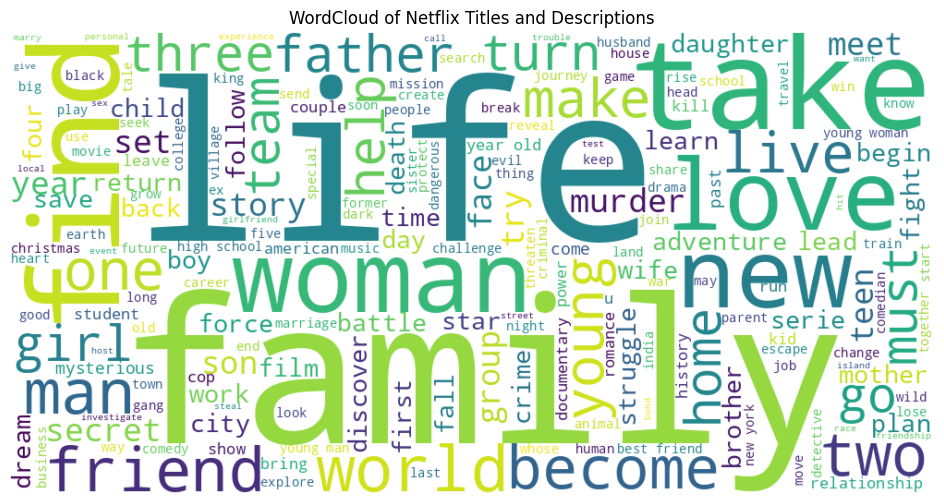


🎭 Sentiment counts:
 sentiment
Positive    4227
Negative    3792
Neutral      788
Name: count, dtype: int64


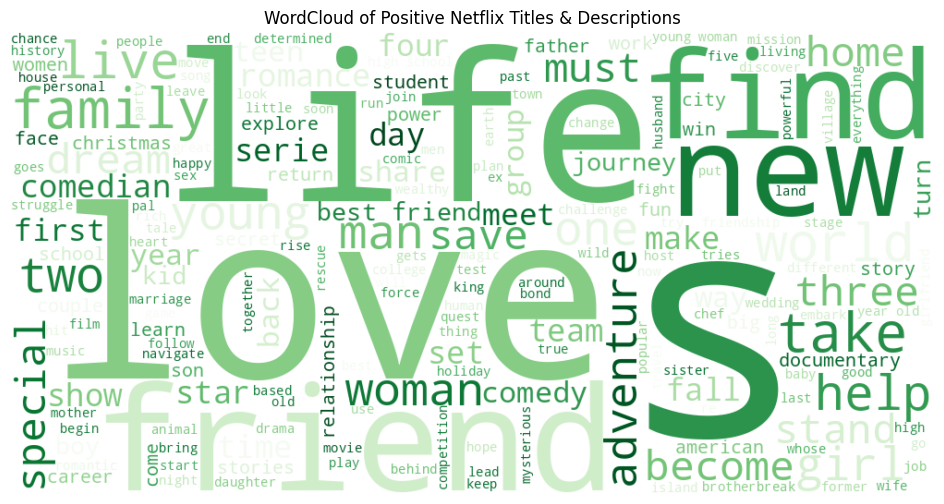

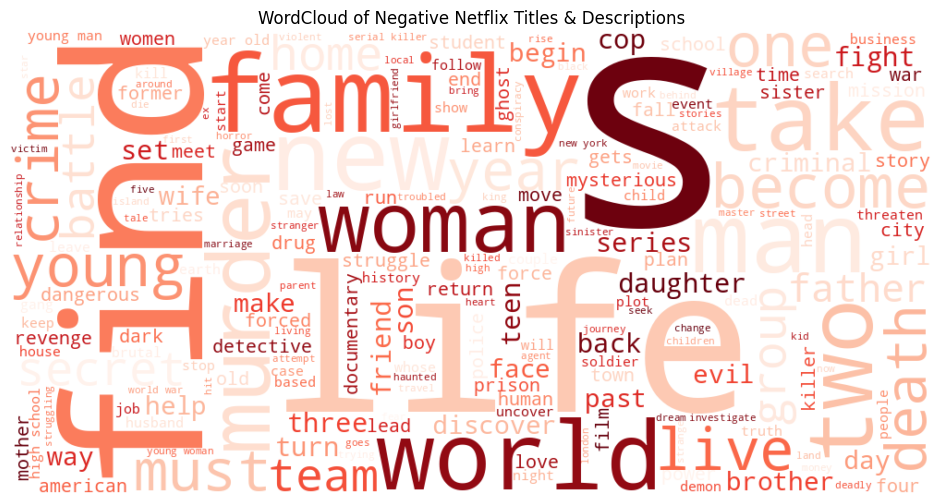

/tmp/ipython-input-2911983043.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette=palette)


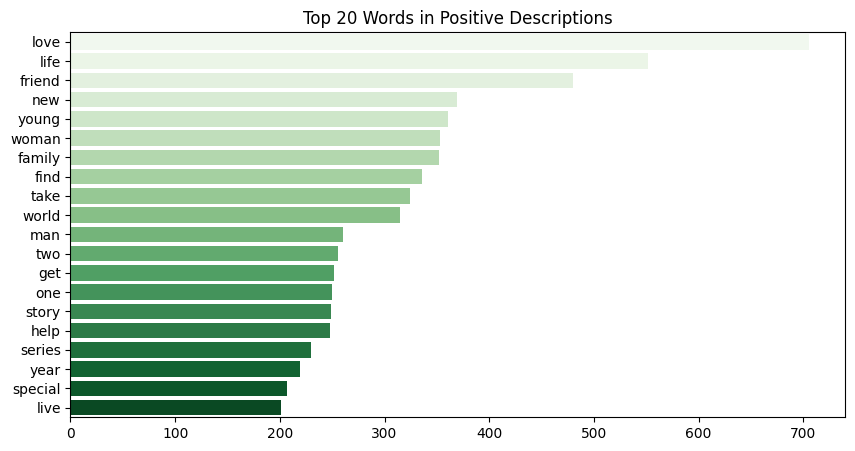

/tmp/ipython-input-2911983043.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette=palette)


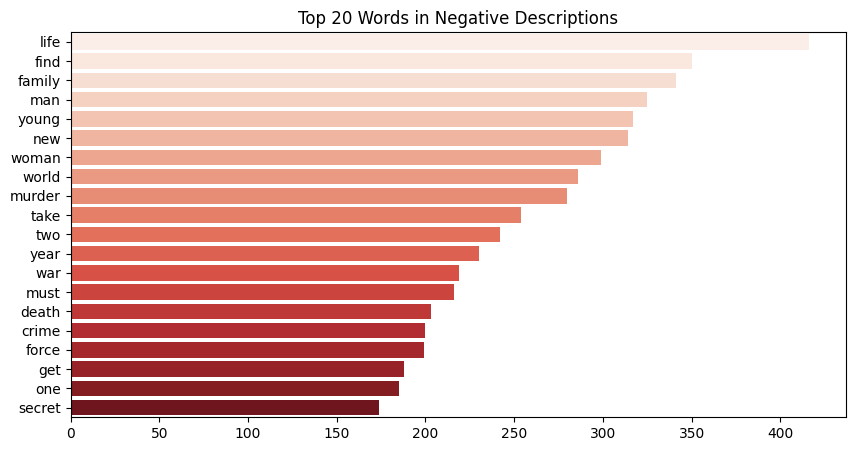


🔢 TF-IDF matrix shape: (8807, 1000)

🧩 Topic 1:
['story', 'love', 'based', 'special', 'world', 'life', 'family', 'war', 'true', 'christmas']

🧩 Topic 2:
['killer', 'drug', 'family', 'small', 'crime', 'murder', 'town', 'woman', 'young', 'man']

🧩 Topic 3:
['music', 'history', 'stand', 'film', 'stories', 'life', 'comedy', 'world', 'series', 'documentary']

🧩 Topic 4:
['girl', 'young', 'woman', 'year old', 'family', 'man', 'year', 'old', 'life', 'love']

🧩 Topic 5:
['york', 'young', 'little', 'help', 'city', 'high school', 'friends', 'high', 'new', 'school']

🎯 Cluster counts:
 cluster
0    5879
2    1543
3     574
1     449
4     362
Name: count, dtype: int64

✅ Enhanced NLP processing complete! Results saved to netflix_nlp_enhanced_sentiment.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from collections import Counter


# NLTK downloads

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')


# Load dataset

df = pd.read_csv("netflix_titles.csv")
print("✅ Dataset loaded:", df.shape)
print(df.head())


# Combine title + description

df['text'] = df['title'].fillna('') + " " + df['description'].fillna('')


# Clean text

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)


# Tokenize + POS-aware Lemmatization

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    pos_tags = pos_tag(tokens)
    tokens = [lemmatizer.lemmatize(word, pos='v' if tag.startswith('V') else 'n') for word, tag in pos_tags]
    return tokens

df['tokens'] = df['clean_text'].apply(preprocess)


# Word Frequency Visualization (All Words)

all_words = [word for tokens in df['tokens'] for word in tokens]
freq_dist = pd.Series(all_words).value_counts().head(20)

plt.figure(figsize=(10,5))
sns.barplot(x=freq_dist.values, y=freq_dist.index, palette="mako")
plt.title("Top 20 Most Common Words in Netflix Descriptions")
plt.show()

# WordCloud (All Words)
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(" ".join(all_words))
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Netflix Titles and Descriptions")
plt.show()


# VADER Sentiment Analysis

sid = SentimentIntensityAnalyzer()
df['vader_score'] = df['clean_text'].apply(lambda x: sid.polarity_scores(x)['compound'])
df['sentiment'] = df['vader_score'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)
print("\n🎭 Sentiment counts:\n", df['sentiment'].value_counts())


# Visualizations by Sentiment


# Function to generate WordCloud
def plot_wordcloud(text, title, colormap='viridis'):
    wordcloud = WordCloud(width=1000, height=500, background_color='white', colormap=colormap).generate(text)
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Positive
positive_text = " ".join(df[df['sentiment']=='Positive']['clean_text'])
plot_wordcloud(positive_text, "WordCloud of Positive Netflix Titles & Descriptions", colormap='Greens')

# Negative
negative_text = " ".join(df[df['sentiment']=='Negative']['clean_text'])
plot_wordcloud(negative_text, "WordCloud of Negative Netflix Titles & Descriptions", colormap='Reds')

# Barplot function for top words
def plot_top_words(tokens_list, title, palette):
    words = [word for tokens in tokens_list for word in tokens]
    freq = Counter(words).most_common(20)
    words, counts = zip(*freq)
    plt.figure(figsize=(10,5))
    sns.barplot(x=counts, y=words, palette=palette)
    plt.title(title)
    plt.show()

# Top words Positive
plot_top_words(df[df['sentiment']=='Positive']['tokens'], "Top 20 Words in Positive Descriptions", "Greens")

# Top words Negative
plot_top_words(df[df['sentiment']=='Negative']['tokens'], "Top 20 Words in Negative Descriptions", "Reds")


# TF-IDF Vectorization with n-grams

tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['clean_text'])
print("\n🔢 TF-IDF matrix shape:", X_tfidf.shape)


# Topic Modeling (LDA)

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_tfidf)

feature_names = tfidf.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    print(f"\n🧩 Topic {i+1}:")
    print([feature_names[j] for j in topic.argsort()[-10:]])


# Optional: KMeans Clustering

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_tfidf)
print("\n🎯 Cluster counts:\n", df['cluster'].value_counts())


# Save results

df.to_csv("netflix_nlp_enhanced_sentiment.csv", index=False)
print("\n✅ Enhanced NLP processing complete! Results saved to netflix_nlp_enhanced_sentiment.csv")


In [ ]:
from google.colab import files
files.download("netflix_nlp_enhanced.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>